<a href="https://colab.research.google.com/github/Eaglepop/CS5100_Final_Project/blob/main/5100_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pneumonia


1 Data preparation

2 Baseline CNN

3 ResNet transfer learning

4 GAN data augmentation

5 Genetic Algorithm hyperparameter search --> Grid and Optuna

6 Evaluation


## 1. Data Preparation

load dataset\
split dataset\
image preprocessing


torchvision\
PIL\
numpy


In [ ]:
!pip install torch torchvision
!pip install kaggle
!pip install scikit-learn
!pip install torch torchvision scikit-learn matplotlib

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os

import kagglehub

In [ ]:
# chest_xray/
#     train/
#         NORMAL/
#         PNEUMONIA/
#     val/
#         NORMAL/
#         PNEUMONIA/
#     test/
#         NORMAL/
#         PNEUMONIA/

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

path = os.path.join(path, "chest_xray")

#Grep train, test, val data
train_dir = os.path.join(path, "train")
val_dir = os.path.join(path, "val")
test_dir = os.path.join(path, "test")

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# load dataset
train_dataset = ImageFolder(train_dir, transform=transform)
val_dataset = ImageFolder(val_dir, transform=transform)
test_dataset = ImageFolder(test_dir, transform=transform)

print("Path to dataset files:", path)
print(train_dataset.classes) #['NORMAL', 'PNEUMONIA']


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia
Path to dataset files: /kaggle/input/chest-xray-pneumonia/chest_xray
['NORMAL', 'PNEUMONIA']


In [ ]:
# Set batch to 32 then load
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # make sure photos will not always the same
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) # only looking for the result
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # only looking for the result

print("Train size:", len(train_dataset)) #5216
print("Validation size:", len(val_dataset)) #16
print("Test size:", len(test_dataset)) #624

Train size: 5216
Validation size: 16
Test size: 624


In [ ]:
# print nums of pneumonia and normal in every sets

from collections import Counter

def count_classes(dataset, name):
    # read only target
    labels = dataset.targets
    counts = Counter(labels)

    # build mapping
    class_to_idx = dataset.class_to_idx
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    print(f"{name} Set:")
    for idx, count in counts.items():
        print(f"  {idx_to_class[idx]}: {count}")
    print(f"  Total: {len(labels)}\n")

count_classes(train_dataset, "Train")
count_classes(val_dataset, "Validation")
count_classes(test_dataset, "Test")

Train Set:
  NORMAL: 1341
  PNEUMONIA: 3875
  Total: 5216

Validation Set:
  NORMAL: 8
  PNEUMONIA: 8
  Total: 16

Test Set:
  NORMAL: 234
  PNEUMONIA: 390
  Total: 624



tensor([0, 0, 1, 1, 1, 1, 1, 1])
torch.Size([32, 3, 224, 224])
['NORMAL', 'PNEUMONIA']


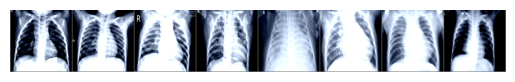

In [ ]:
# Only for visualization

# Denormalization 0~1
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")


dataiter = iter(train_loader) # initialize
images, labels = next(dataiter) # get one batch

imshow(torchvision.utils.make_grid(images[:8]))
print(labels[:8])

print(images.shape) #torch.Size([32, 3, 224, 224])
# 32,         3,           224,    224
# batch_size, RGB channel, height, width

class_names = train_dataset.classes
print(class_names)

## 2. Baseline CNN

Conv\
ReLU\
MaxPool\
Conv\
ReLU\
MaxPool\
Fully connected\
Softmax

In [ ]:
import torch.nn as nn           # instance
import torch.nn.functional as F # Calculate

In [ ]:
# establish baseline CNN model
class SimpleCNN(nn.Module):

    def __init__(self): #initializtion
        super(SimpleCNN, self).__init__()

        #nn.Conv2d(in, out, kernel, padding)

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):

        #224*224*3
        x = self.pool(F.relu(self.conv1(x))) #112*112*16
        #112*112*16
        x = self.pool(F.relu(self.conv2(x))) #56*56*32

        #Flatten to 1d line with length == 56*56*32
        x = x.view(x.size(0), -1) # size(0)= default batch size (32), -1: calculate it automatically
        #x.size() = [batch, channel, length, width] --> 32, 32, 56, 56

        x = F.relu(self.fc1(x)) # 32 * 56 * 56 --> 128
        x = self.fc2(x) # 128 --> 2

        return x # (x is logits(can >1, <0), not confidence(prob) yet)

In [ ]:
# set up env
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # specify env

model = SimpleCNN().to(device) # put model into env

print(model)


SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


In [ ]:
#loss
criterion = nn.CrossEntropyLoss() #loss as criterion

#optimizer: Adam
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
#Training loop

#input batch
#generate logits
#criterion calculate loss
#.backward find gradients
#optimizer.step revise parameters

epochs = 5

for epoch in range(epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # reset to 0

        outputs = model(images) # train in model(simpleCNN)

        loss = criterion(outputs, labels) # grading

        loss.backward() # back propagation

        optimizer.step() # gradually optimize

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.4062
Epoch 2, Loss: 0.1911
Epoch 3, Loss: 0.1524
Epoch 4, Loss: 0.1247
Epoch 5, Loss: 0.1038


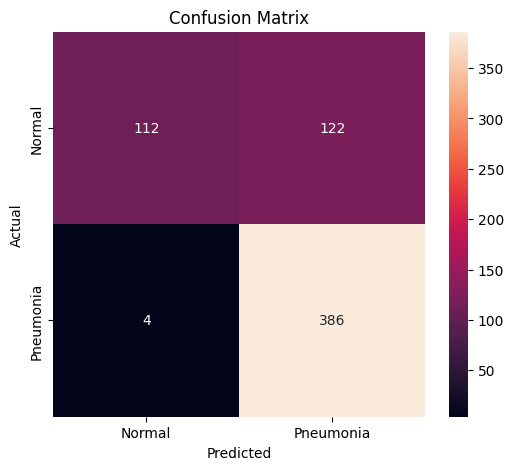

              precision    recall  f1-score   support

           0       0.97      0.48      0.64       234
           1       0.76      0.99      0.86       390

    accuracy                           0.80       624
   macro avg       0.86      0.73      0.75       624
weighted avg       0.84      0.80      0.78       624



In [ ]:
# evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
import seaborn as sns

all_preds=[]  # predict labels
all_labels=[] # true labels
all_probs=[]  # probabilities of Pnuemonia

model.eval() # set model to evaluation mode

# eval loop
with torch.no_grad(): # do not track gradient in order to decrease the using of the resources (we don't have to update parameters during evaluation)

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images) # oroginal output (logits)

        probs = torch.softmax(outputs, dim=1) # turn logits into probabilities (sum=1 in each class)

        _, predicted = torch.max(outputs, 1) # _ is the max logit in the original output, we do not need this anymore so just recieve "predicted" which is 0 or 1

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Precision / Recall / F1 score
print(classification_report(all_labels, all_preds))


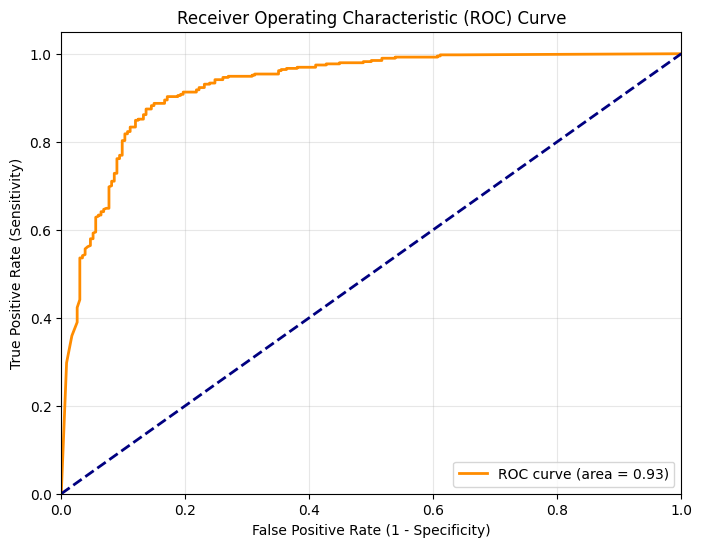

ROC-AUC Score: 0.9272


In [ ]:
# AUROC curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate points of ROC curve (FPR, TPR)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# Calculate roc_auc
roc_auc = auc(fpr, tpr)

# draw the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # give the curve more space
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('SimpleCNN AUROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")


## 3. Resnet Transfer Learning

load pretrained resnet\
replace final layer\
train classifier

In [ ]:
import torchvision.models as models

# model = models.resnet18(pretrained = True) # conventional
model = models.resnet18(weights='DEFAULT') # select the most suitable weight

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


In [ ]:
num_ft = model.fc.in_features
model.fc = nn.Linear(num_ft,2)

In [ ]:
for param in model.parameters():
  param.requires_grad = False

for param in model.fc.parameters():
  param.requires_grad = True

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

In [ ]:
epochs = 5

for epoch in range(epochs):
  model.train()
  running_loss=0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

  print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/5, Loss: 0.2737
Epoch 2/5, Loss: 0.1671
Epoch 3/5, Loss: 0.1471


In [ ]:
# evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
import seaborn as sns

all_preds=[]  # predict labels
all_labels=[] # true labels
all_probs=[]  # probabilities of Pnuemonia

model.eval() # set model to evaluation mode

# eval loop
with torch.no_grad(): # do not track gradient in order to decrease the using of the resources (we don't have to update parameters during evaluation)

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images) # oroginal output (logits)

        probs = torch.softmax(outputs, dim=1) # turn logits into probabilities (sum=1 in each class)

        _, predicted = torch.max(outputs, 1) # _ is the max logit in the original output, we do not need this anymore so just recieve "predicted" which is 0 or 1

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Precision / Recall / F1 score
print(classification_report(all_labels, all_preds))


In [ ]:
# AUROC curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate points of ROC curve (FPR, TPR)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# Calculate roc_auc
roc_auc = auc(fpr, tpr)

# draw the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ResNet AUROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")


## 4. GAN Data Augmentation

train GAN\
generate images\
add to dataset

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.utils as vutils

In [ ]:
image_size = 64   # GAN 用小圖比較穩
batch_size = 64
nz = 100          # noise vector

In [ ]:
transform_gan = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
gan_dataset = ImageFolder(train_dir, transform=transform_gan)

# ★改這裡：只取 NORMAL（label = 0）
indices = [i for i, (_, label) in enumerate(gan_dataset) if label == 0]

gan_subset = torch.utils.data.Subset(gan_dataset, indices)

gan_loader = DataLoader(gan_subset, batch_size=batch_size, shuffle=True)

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, 64, 4, 1, 0),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(64*16*16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)

In [ ]:
# initialization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

netG = Generator().to(device)
netD = Discriminator().to(device)

criterion = nn.BCELoss()

optimizerG = torch.optim.Adam(netG.parameters(), lr=0.0002)
optimizerD = torch.optim.Adam(netD.parameters(), lr=0.0002)

NameError: name 'torch' is not defined

In [ ]:
epochs = 5

for epoch in range(epochs):
    for real, _ in gan_loader:

        real = real.to(device)   # ★已經是 grayscale，不用 [:,0:1,:,:]

        b_size = real.size(0)

        label_real = torch.ones(b_size, 1).to(device)
        label_fake = torch.zeros(b_size, 1).to(device)

        # --- Train Discriminator ---
        output_real = netD(real)
        loss_real = criterion(output_real, label_real)

        noise = torch.randn(b_size, nz, 1, 1).to(device)
        fake = netG(noise)

        output_fake = netD(fake.detach())
        loss_fake = criterion(output_fake, label_fake)

        lossD = loss_real + loss_fake

        optimizerD.zero_grad()
        lossD.backward()
        optimizerD.step()

        # --- Train Generator ---
        output = netD(fake)
        lossG = criterion(output, label_real)

        optimizerG.zero_grad()
        lossG.backward()
        optimizerG.step()

    print(f"Epoch {epoch+1} done")

In [ ]:
num_generate = 300

noise = torch.randn(num_generate, nz, 1, 1).to(device)
fake_images = netG(noise)

In [ ]:
import os

# ★改這裡：新資料夾（不要污染原 dataset）
save_dir = "chest_xray/train_augmented/NORMAL/"
os.makedirs(save_dir, exist_ok=True)

# ★每張分開存
for i in range(fake_images.size(0)):
    vutils.save_image(fake_images[i], save_dir + f"gan_normal_{i}.png", normalize=True)

In [ ]:
## ResNet + GAN

train_dir = "chest_xray/train_augmented"   # change dataset to augmented dataset
val_dir = "chest_xray/val"
test_dir = "chest_xray/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # ★重要（ResNet要3通道）
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                     [0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(train_dir, transform=transform)
val_dataset = ImageFolder(val_dir, transform=transform)
test_dataset = ImageFolder(test_dir, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)



# model = models.resnet18(pretrained = True) # conventional
model = models.resnet18(weights='DEFAULT') # select the most suitable weight



num_ft = model.fc.in_features
model.fc = nn.Linear(num_ft,2)



for param in model.parameters():
  param.requires_grad = False

for param in model.fc.parameters():
  param.requires_grad = True



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)



criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)



epochs = 5

for epoch in range(epochs):
  model.train()
  running_loss=0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

  print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")




In [ ]:
# evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
import seaborn as sns

all_preds=[]  # predict labels
all_labels=[] # true labels
all_probs=[]  # probabilities of Pnuemonia

model.eval() # set model to evaluation mode

# eval loop
with torch.no_grad(): # do not track gradient in order to decrease the using of the resources (we don't have to update parameters during evaluation)

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images) # oroginal output (logits)

        probs = torch.softmax(outputs, dim=1) # turn logits into probabilities (sum=1 in each class)

        _, predicted = torch.max(outputs, 1) # _ is the max logit in the original output, we do not need this anymore so just recieve "predicted" which is 0 or 1

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet + GAN  Confusion Matrix")
plt.show()

# Precision / Recall / F1 score
print(classification_report(all_labels, all_preds))


In [ ]:
# AUROC curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate points of ROC curve (FPR, TPR)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# Calculate roc_auc
roc_auc = auc(fpr, tpr)

# draw the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ResNet + GAN  AUROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

## 5. Grid Hyperparamter Search

learning rate\
batch size\
optimizer\
dropout

In [ ]:
train_dir = "chest_xray/train"
val_dir = "chest_xray/val"
test_dir = "chest_xray/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(train_dir, transform=transform)
test_dataset = ImageFolder(test_dir, transform=transform)


In [ ]:
# Grid setting
learning_rates = [0.001, 0.0001]
batch_sizes = [16, 32]


best_acc = 0
best_config = {}
best_model = None

for lr in learning_rates:
    for batch_size in batch_sizes:

        print(f"\nRunning: lr={lr}, batch_size={batch_size}")

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        # Model
        model = models.resnet18(weights='DEFAULT')
        num_ft = model.fc.in_features
        model.fc = nn.Linear(num_ft, 2)

        # Freeze
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True

        model = model.to(device)

        # Loss
        criterion = nn.CrossEntropyLoss()

        # Optimizer
        optimizer = torch.optim.Adam(model.fc.parameters(), lr=lr)

        # Train
        epochs = 5
        for epoch in range(epochs):
            model.train()
            for images, labels in train_loader:

                images = images.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        # Evaluate (accuracy)
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        print(f"Accuracy: {acc:.2f}%")

        # Save best model ★
        if acc > best_acc:
            best_acc = acc
            best_config = {"lr": lr, "batch_size": batch_size}
            best_model = model

In [ ]:
print("\nBest Config:", best_config)
print("Best Accuracy:", best_acc)

In [ ]:
# evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
import seaborn as sns

all_preds=[]  # predict labels
all_labels=[] # true labels
all_probs=[]  # probabilities of Pnuemonia

model.eval() # set model to evaluation mode

# eval loop
with torch.no_grad(): # do not track gradient in order to decrease the using of the resources (we don't have to update parameters during evaluation)

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images) # oroginal output (logits)

        probs = torch.softmax(outputs, dim=1) # turn logits into probabilities (sum=1 in each class)

        _, predicted = torch.max(outputs, 1) # _ is the max logit in the original output, we do not need this anymore so just recieve "predicted" which is 0 or 1

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet + GridSearch  Confusion Matrix")
plt.show()

# Precision / Recall / F1 score
print(classification_report(all_labels, all_preds))


In [ ]:
# AUROC curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate points of ROC curve (FPR, TPR)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# Calculate roc_auc
roc_auc = auc(fpr, tpr)

# draw the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ResNet + GridSearch  AUROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

## 6. Optuna Hyperparamter Search

learning rate\
batch size\
optimizer\
dropout

In [ ]:
# evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
import seaborn as sns

all_preds=[]  # predict labels
all_labels=[] # true labels
all_probs=[]  # probabilities of Pnuemonia

model.eval() # set model to evaluation mode

# eval loop
with torch.no_grad(): # do not track gradient in order to decrease the using of the resources (we don't have to update parameters during evaluation)

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images) # oroginal output (logits)

        probs = torch.softmax(outputs, dim=1) # turn logits into probabilities (sum=1 in each class)

        _, predicted = torch.max(outputs, 1) # _ is the max logit in the original output, we do not need this anymore so just recieve "predicted" which is 0 or 1

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet + Optuna  Confusion Matrix")
plt.show()

# Precision / Recall / F1 score
print(classification_report(all_labels, all_preds))


In [ ]:
# AUROC curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate points of ROC curve (FPR, TPR)
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

# Calculate roc_auc
roc_auc = auc(fpr, tpr)

# draw the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ResNet + Optuna  AUROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

## 7. Evaluation

accuracy\
precision\
recall\
F1 score\
ROC AUC\
confusion matrix